In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("../dataset/preprocessed_dataset.csv")

In [3]:
print(df.head())
print(df.columns)

   area  num_bath_rooms  num_bed_rooms       price  locality  \
0  2464               4              3  28900000.0        61   
1  1920               3              3  20000000.0        37   
2  1445               3              3  10800000.0        25   
3  1475               3              3  10500000.0       178   
4  1066               2              3   8000000.0       166   

   relaxation_amenity_count  security_amenity_count  \
0                         1                       2   
1                         1                       1   
2                         1                       2   
3                         1                       2   
4                         1                       1   

   maintenance_or_cleaning_amenity_count  social_amenity_count  \
0                                      1                     1   
1                                      2                     1   
2                                      2                     1   
3                   

In [4]:
X = df.drop(columns=["price"])
y = df["price"]

Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Scaling

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Linear Regression

In [7]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

pred_lr = lr.predict(X_test_scaled)

Decision Tree Regression

In [8]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

Random Forest

In [9]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

Gradient Boost Regression

In [10]:
gb = GradientBoostingRegressor()
gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

Support Vector Regression

In [12]:
svr = SVR()
svr.fit(X_train_scaled, y_train)

pred_svr = svr.predict(X_test_scaled)

Model Result

In [13]:
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "SVR"
    ],
    "R2 Score":[
        r2_score(y_test,pred_lr),
        r2_score(y_test,pred_dt),
        r2_score(y_test,pred_rf),
        r2_score(y_test,pred_gb),
        r2_score(y_test,pred_svr)
    ]
})

print("\nModel Comparison")
print(results)


best_model = results.loc[results["R2 Score"].idxmax()]

print("\nBest Model:")
print(best_model)


Model Comparison
               Model  R2 Score
0  Linear Regression  0.792180
1      Decision Tree  0.986777
2      Random Forest  0.992953
3  Gradient Boosting  0.991592
4                SVR -0.293762

Best Model:
Model       Random Forest
R2 Score         0.992953
Name: 2, dtype: object


Feature Used Mostly

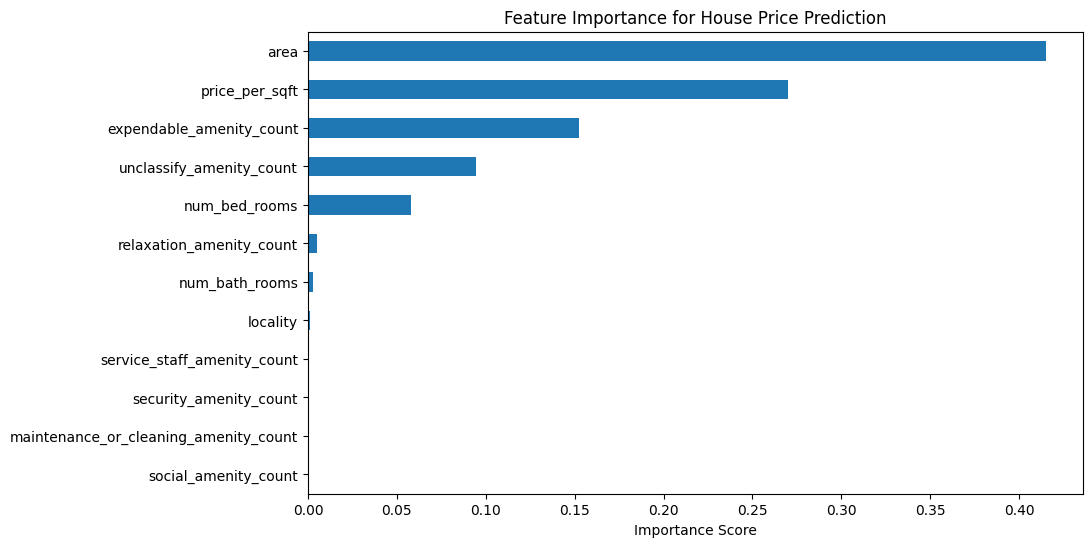

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

feature_importance.sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Feature Importance for House Price Prediction")
plt.xlabel("Importance Score")

plt.show()

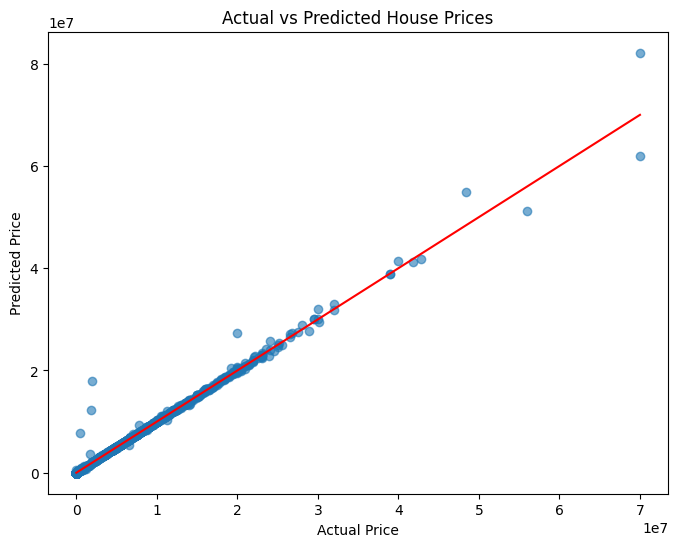

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred_rf, alpha=0.6)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.show()